In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import CSVLogger
import os

In [2]:
# Load and clean data
df = pd.read_csv('C:/Users/Admin/OneDrive/Desktop/live_headlines.csv')
df = df.drop_duplicates(subset=['headline'])
df = df[df['Sentiment'].isin(['Positive', 'Neutral', 'Negative'])]
X = df['headline']
y = df['Sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Save cleaned data to a new CSV file
output_path = 'C:/Users/Admin/OneDrive/Desktop/cleaned_headlines.csv'
df.to_csv(output_path, index=False)
print(f"Cleaned data saved to: {output_path}")

Cleaned data saved to: C:/Users/Admin/OneDrive/Desktop/cleaned_headlines.csv


In [3]:
# TF-IDF + Logistic Regression with GridSearchCV
pipe = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__max_features': [5000],
    'clf__C': [0.5, 1.0]
}
gs = GridSearchCV(pipe, param_grid, cv=3, scoring='f1_weighted', verbose=1)
gs.fit(X_train, y_train)
joblib.dump(gs.best_estimator_, 'logreg_model.joblib')
y_pred = gs.predict(X_test)
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 4 candidates, totalling 12 fits
              precision    recall  f1-score   support

    Negative       0.31      0.29      0.30        17
     Neutral       0.73      0.79      0.76        75
    Positive       0.54      0.45      0.49        33

    accuracy                           0.63       125
   macro avg       0.53      0.51      0.52       125
weighted avg       0.62      0.63      0.62       125



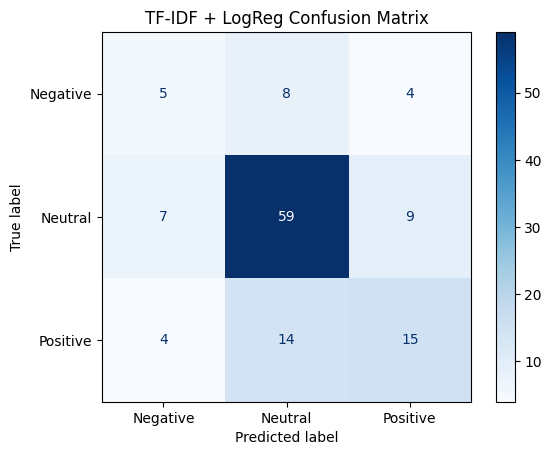

In [4]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['Negative', 'Neutral', 'Positive'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Neutral', 'Positive'])
disp.plot(cmap='Blues')
plt.title('TF-IDF + LogReg Confusion Matrix')
plt.show()

In [5]:
# LSTM pipeline
max_words, max_len = 10000, 30
tok = Tokenizer(num_words=max_words, oov_token='<OOV>')
tok.fit_on_texts(X_train)
X_train_pad = pad_sequences(tok.texts_to_sequences(X_train), maxlen=max_len)
X_test_pad = pad_sequences(tok.texts_to_sequences(X_test), maxlen=max_len)
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
y_train_cat = to_categorical(y_train.map(label_map))
y_test_cat = to_categorical(y_test.map(label_map))

In [6]:
# Build and train LSTM
model = Sequential([
    Embedding(max_words, 64, input_length=max_len),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
csv_logger = CSVLogger('lstm_training_log.csv')
history = model.fit(X_train_pad, y_train_cat, epochs=6, batch_size=32, validation_split=0.1, callbacks=[csv_logger])
model.save('lstm_model.keras')
loss, acc = model.evaluate(X_test_pad, y_test_cat)
print(f'LSTM Test Accuracy: {acc:.4f}')

C:\preet\envs\sentiment_env\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/6
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.5088 - loss: 1.0727 - val_accuracy: 0.5800 - val_loss: 0.9719
Epoch 2/6
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6154 - loss: 0.8998 - val_accuracy: 0.5800 - val_loss: 0.9663
Epoch 3/6
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6284 - loss: 0.8720 - val_accuracy: 0.5800 - val_loss: 0.9733
Epoch 4/6
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.6155 - loss: 0.8359 - val_accuracy: 0.5800 - val_loss: 0.9873
Epoch 5/6
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6396 - loss: 0.7445 - val_accuracy: 0.5800 - val_loss: 0.9589
Epoch 6/6
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.6702 - loss: 0.6635 - val_accuracy: 0.6000 - val_loss: 0.9521
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6037 - loss: 0.8804
LSTM Test Accuracy: 0.6160


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


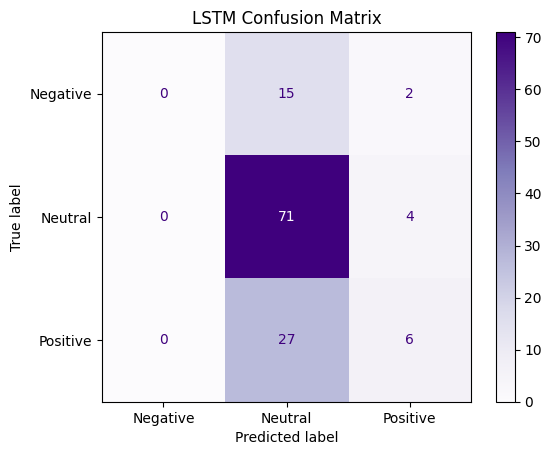

In [7]:
# LSTM Confusion Matrix
y_pred_lstm = model.predict(X_test_pad).argmax(axis=1)
y_true_lstm = y_test.map(label_map).values
cm_lstm = confusion_matrix(y_true_lstm, y_pred_lstm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lstm, display_labels=['Negative', 'Neutral', 'Positive'])
disp.plot(cmap='Purples')
plt.title('LSTM Confusion Matrix')
plt.show()

LLM Prompts


Solved error while training lstm